In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
%matplotlib inline
import warnings
warnings.simplefilter('ignore')

In [17]:
# Making Dataset (linear)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=1, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

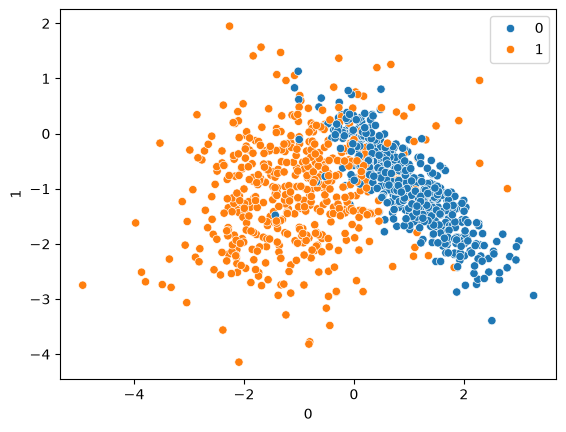

In [18]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [19]:
# Train test split
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [20]:
# Training by SVM
lin = skl.svm.SVC(kernel="linear")
lin.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
y_pred = lin.predict(X_test)

In [22]:
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[118   5]
 [ 22 105]]
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       123
           1       0.95      0.83      0.89       127

    accuracy                           0.89       250
   macro avg       0.90      0.89      0.89       250
weighted avg       0.90      0.89      0.89       250



In [23]:
# Making Dataset (overlapping)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=2, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

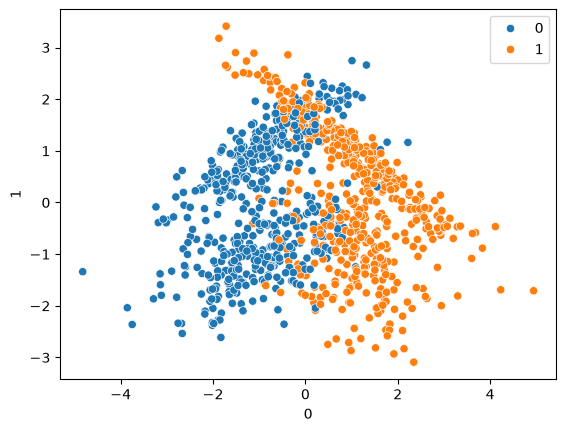

In [24]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

### Using multiple kernels to check which one gives better accuracy

In [26]:
rbf = skl.svm.SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred = rbf.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[119   4]
 [ 23 104]]
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       123
           1       0.96      0.82      0.89       127

    accuracy                           0.89       250
   macro avg       0.90      0.89      0.89       250
weighted avg       0.90      0.89      0.89       250



In [27]:
sigmoid = skl.svm.SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
y_pred = sigmoid.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[100  23]
 [ 36  91]]
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       123
           1       0.80      0.72      0.76       127

    accuracy                           0.76       250
   macro avg       0.77      0.76      0.76       250
weighted avg       0.77      0.76      0.76       250



In [28]:
poly = skl.svm.SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred = poly.predict(X_test)
print(skl.metrics.confusion_matrix(y_test,y_pred))
print(skl.metrics.classification_report(y_test,y_pred))

[[123   0]
 [ 36  91]]
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       123
           1       1.00      0.72      0.83       127

    accuracy                           0.86       250
   macro avg       0.89      0.86      0.85       250
weighted avg       0.89      0.86      0.85       250

